# Exercise 18: Principal component methods

This homework assignment is designed to give you an intuition on principal component approaches to understanding high dimensional statistical relationships.

Like earlier homework, you will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measuresments from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

---
## 1. Loading data (1 point)

We are going to look for low dimensional relationships between brain volume measures and working memory capacity.

First, we will need to load the `pls`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [7]:
#install.packages("pls") # Uncomment if not installed
library(pls) # load for the pcr function
library(tidyverse)
library(ggplot2)

Use `read.csv` function to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file in the **hcp_data** folder.

(a) Using the tidyverse tools, make a new dataframe `d1` that only includes the Flanker Task performance (`Flanker_Unadj`) and *all* freesurfer **volume** measures for the right and left hemispheres together. Remove both "na's" and any columns that consist of only zeros.

Hint: Look up using the `ends_with` function to only select variables that end with "_Vol"

Use the `head` function to look at the first few rows of each data frame.

In [9]:
getwd()
setwd('/Users/tamarjaparidze/Documents/DataSciencePsychNeuro/Exercise datasets/hcp_data')
all_data <- read.csv("unrestricted_trimmed_1_7_2020_10_50_44.csv")
#head(all_data,10)

d1 <- all_data %>% #select desired columns -- in this case all the volume columns
  select(Flanker_Unadj, ends_with("_Vol")) 

d1 <- drop_na(d1) #remove all NAs

d1 <- d1 %>%
  select(where(~any(. != 0))) #remove columns with all 0-s

head(d1,10)

[1] "/Users/tamarjaparidze/Documents/DataSciencePsychNeuro/Exercise datasets/hcp_data"

,Flanker_Unadj,FS_IntraCranial_Vol,FS_BrainSeg_Vol,FS_LCort_GM_Vol,FS_RCort_GM_Vol,FS_TotCort_GM_Vol,FS_SubCort_GM_Vol,FS_Total_GM_Vol,FS_SupraTentorial_Vol,FS_L_WM_Vol,⋯,FS_R_Vessel_Vol,FS_R_ChoroidPlexus_Vol,FS_5thVent_Vol,FS_WM_Hypointens_Vol,FS_OpticChiasm_Vol,FS_CC_Posterior_Vol,FS_CC_MidPosterior_Vol,FS_CC_Central_Vol,FS_CC_MidAnterior_Vol,FS_CC_Anterior_Vol
,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,130.42,1864518,1406924,304488,305634,610122,70240,807245,1239692,269963,⋯,80,1613,0,1269,325,800,409,569,522,813
2,112.56,1512540,1109710,240030,243207,483238,56623,664124,957615,203472,⋯,70,1007,0,1155,195,1029,526,578,576,649
3,121.18,1684117,1280171,260695,265243,525938,63869,726206,1106881,247504,⋯,88,1303,0,1279,302,972,589,528,471,858
4,126.53,1816044,1321362,276506,278002,554508,74869,762308,1155067,254742,⋯,81,909,0,1154,296,1065,618,838,729,1072
5,101.85,1437868,1053766,203718,210539,414257,58813,579632,916973,213012,⋯,75,1215,3,377,235,1057,591,538,430,849
6,107.04,1512727,1126655,242489,248807,491296,62092,665024,984952,205342,⋯,93,1331,17,554,258,1033,494,487,489,992
7,113.67,1540433,1239152,264768,270079,534847,59937,707674,1094546,241356,⋯,2,1105,0,2221,186,1050,498,796,589,921
8,108.46,1824028,1328259,287013,299163,586176,62680,773472,1170042,248210,⋯,167,1756,0,1084,205,1111,382,482,531,1014
9,98.94,1485035,1122818,247478,250042,497520,57557,676282,971287,201751,⋯,90,996,0,816,219,992,679,712,657,881


---
## 2. Correlational structure (4 points)

(a) Take a look at the correlation between all of the freesurfer volume measures ("FS_") using the `cor` function. Create a new variable called `fs_cor` that is the correlation matrix for only the freesurfer volumes

In [14]:
fs_cor <- cor(d1[,2:length(d1)])
fs_cor

,FS_IntraCranial_Vol,FS_BrainSeg_Vol,FS_LCort_GM_Vol,FS_RCort_GM_Vol,FS_TotCort_GM_Vol,FS_SubCort_GM_Vol,FS_Total_GM_Vol,FS_SupraTentorial_Vol,FS_L_WM_Vol,FS_R_WM_Vol,⋯,FS_R_Vessel_Vol,FS_R_ChoroidPlexus_Vol,FS_5thVent_Vol,FS_WM_Hypointens_Vol,FS_OpticChiasm_Vol,FS_CC_Posterior_Vol,FS_CC_MidPosterior_Vol,FS_CC_Central_Vol,FS_CC_MidAnterior_Vol,FS_CC_Anterior_Vol
FS_IntraCranial_Vol,1.00000000,0.89775779,0.84001739,0.8439151,0.84527801,0.78851398,0.8751297,0.88515809,0.83110860,0.82780629,⋯,0.15363321,0.428612089,0.087584249,0.222582581,0.33097622,0.34486799,0.18960892,0.197341425,0.284599652,0.40182119
FS_BrainSeg_Vol,0.89775779,1.00000000,0.94481588,0.9482717,0.95026178,0.86899391,0.9664839,0.99584206,0.95025059,0.94827234,⋯,0.20678367,0.412581030,0.049790923,0.323144337,0.35006717,0.37677373,0.27243466,0.270768619,0.353484192,0.43087227
FS_LCort_GM_Vol,0.84001739,0.94481588,1.00000000,0.9844592,0.99601958,0.78978633,0.9821287,0.94856174,0.82823562,0.82204438,⋯,0.17001517,0.351647503,0.027475287,0.327222174,0.27354855,0.25151569,0.19618089,0.208943426,0.257297934,0.31406264
FS_RCort_GM_Vol,0.84391512,0.94827175,0.98445925,1.0000000,0.99619391,0.79257235,0.9830322,0.95186738,0.83308464,0.83075164,⋯,0.17595431,0.344117704,0.034303100,0.339033622,0.28341844,0.24448681,0.19182668,0.211885362,0.259001604,0.30540697
FS_TotCort_GM_Vol,0.84527801,0.95026178,0.99601958,0.9961939,1.00000000,0.79428656,0.9864250,0.95394600,0.83393307,0.82967591,⋯,0.17369412,0.349199524,0.031048540,0.334495942,0.27962765,0.24893064,0.19473767,0.211253307,0.259167897,0.31089656
FS_SubCort_GM_Vol,0.78851398,0.86899391,0.78978633,0.7925724,0.79428656,1.00000000,0.8407289,0.85912648,0.82483108,0.82505024,⋯,0.23081438,0.381043922,0.028549272,0.277929493,0.32808259,0.36367157,0.31694057,0.270171847,0.332095449,0.40412120
FS_Total_GM_Vol,0.87512975,0.96648393,0.98212867,0.9830322,0.98642496,0.84072890,1.0000000,0.95676918,0.84630850,0.84265274,⋯,0.19061124,0.365072324,0.036498799,0.327752825,0.30026585,0.26509338,0.21393596,0.227828080,0.273788710,0.32692300
FS_SupraTentorial_Vol,0.88515809,0.99584206,0.94856174,0.9518674,0.95394600,0.85912648,0.9567692,1.00000000,0.95657235,0.95448952,⋯,0.20303200,0.410095816,0.047016231,0.326916622,0.34304042,0.38403125,0.27388840,0.268821695,0.356887229,0.43655852
FS_L_WM_Vol,0.83110860,0.95025059,0.82823562,0.8330846,0.83393307,0.82483108,0.8463085,0.95657235,1.00000000,0.99720862,⋯,0.20733288,0.360053967,0.041169736,0.312125828,0.35983007,0.46628464,0.37067576,0.352852343,0.445780348,0.50126064
FS_R_WM_Vol,0.82780629,0.94827234,0.82204438,0.8307516,0.82967591,0.82505024,0.8426527,0.95448952,0.99720862,1.00000000,⋯,0.20560868,0.360960457,0.041746175,0.316231493,0.36438062,0.46048694,0.36768598,0.351758721,0.441418100,0.49765782


(b) Load (and install locally if needed) the `reshape2` library in order to use the `melt` function on the new `fs_cor` object. Use `head` to show the new, melted `fs_cor` object.

In [20]:
#install.packages("reshape2") # Uncomment if not installed
library(reshape2)
fs_cor_melted <- melt(fs_cor) #"melt converts a wide cormat into a longer data frame w dims var1, var2, value (each combination of variables presented as a row) 
head(fs_cor_melted,15)

,Var1,Var2,value
,<fct>,<fct>,<dbl>
1,FS_IntraCranial_Vol,FS_IntraCranial_Vol,1.0000000
2,FS_BrainSeg_Vol,FS_IntraCranial_Vol,0.8977578
3,FS_LCort_GM_Vol,FS_IntraCranial_Vol,0.8400174
4,FS_RCort_GM_Vol,FS_IntraCranial_Vol,0.8439151
5,FS_TotCort_GM_Vol,FS_IntraCranial_Vol,0.8452780
6,FS_SubCort_GM_Vol,FS_IntraCranial_Vol,0.7885140
7,FS_Total_GM_Vol,FS_IntraCranial_Vol,0.8751297
8,FS_SupraTentorial_Vol,FS_IntraCranial_Vol,0.8851581
9,FS_L_WM_Vol,FS_IntraCranial_Vol,0.8311086


Plot the correlation as a heatmap using `ggplot2`.

Hint: use the `scale_fill_gradient2` function to scale the colors between red and blue, capping the values at -1 and +1.

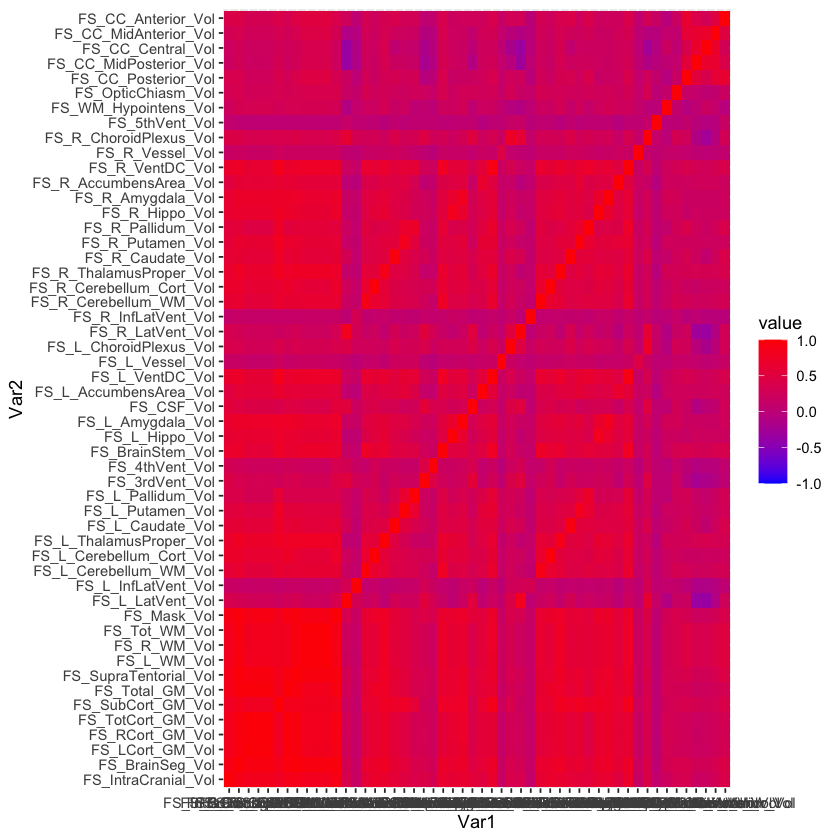

In [25]:
ggplot(data=fs_cor_melted, aes(x=Var1, y=Var2, fill=value)) + 
    geom_tile() + 
    scale_fill_gradient(low = "blue", high = "red", limits = c(-1,1)) #+ 
    #coord_fixed() #makes the output heatmap square

What patterns do you see in the correlations?

> There are distinct same-colored rectangles in the correlations: it seems like the first ~12 variables are all highly correlated with each other. They continue to be correlated with most other variables, except more ventral volumes as evinced by darker streaks. Generally, it seems like these ventral areas are the least correlated with other regions. 

---
## 3. Principal component analysis (3 points)

Let's see how many principal components explain at *at least* 95% of the data.

(a) Create a new object called `fs_d.pca` using the `princomp` function (do not forget to scale the data).


In [29]:
fs_d.pca <- prcomp(d1[,2:length(d1)],scale. = TRUE) #I used prcomp because it was used in the tutorial and allows for scale as an argument
summary(fs_d.pca)

Importance of components:
                          PC1     PC2    PC3     PC4     PC5   PC6     PC7
Standard deviation     4.8304 2.07735 1.6570 1.45428 1.30624 1.163 1.13995
Proportion of Variance 0.4487 0.08299 0.0528 0.04067 0.03281 0.026 0.02499
Cumulative Proportion  0.4487 0.53170 0.5845 0.62517 0.65799 0.684 0.70898
                           PC8     PC9    PC10    PC11    PC12    PC13    PC14
Standard deviation     1.06535 1.04640 1.01825 0.96725 0.92602 0.90433 0.86368
Proportion of Variance 0.02183 0.02106 0.01994 0.01799 0.01649 0.01573 0.01435
Cumulative Proportion  0.73081 0.75186 0.77180 0.78979 0.80628 0.82201 0.83636
                          PC15   PC16    PC17    PC18    PC19    PC20    PC21
Standard deviation     0.80339 0.7900 0.76513 0.74691 0.73291 0.71637 0.66947
Proportion of Variance 0.01241 0.0120 0.01126 0.01073 0.01033 0.00987 0.00862
Cumulative Proportion  0.84877 0.8608 0.87203 0.88276 0.89309 0.90296 0.91158
                          PC22    PC23    PC24

(b) Calculate the cumulative variance explained (not unique variance explained as in the tutorial) across the principal components and plot the results using `ggplot`.

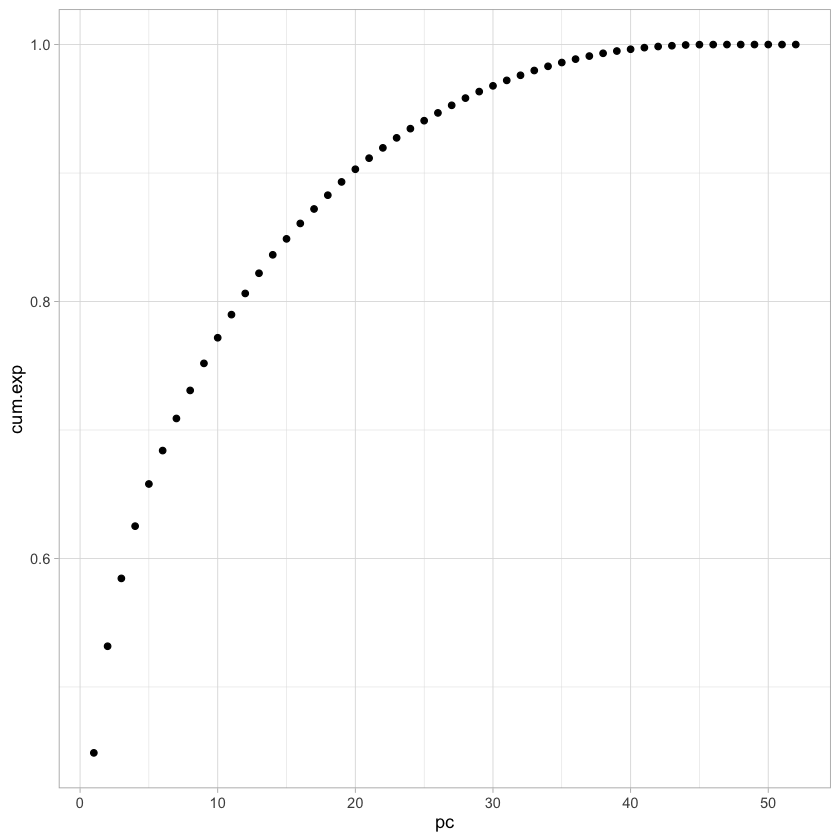

In [36]:
ggplot(data.frame(pc=1:52,cum.exp=cumsum((fs_d.pca$sdev^2) / sum(fs_d.pca$sdev^2))), #chatGPT helped me with the syntax for cumulative sum
        aes(x=pc,y=cum.exp)) + 
    geom_point() + 
    theme_light()

(c) Determine exactly how many principal components explain at least 95% of the variance.

Hint: Look up the `which` function.

In [42]:
which(summary(fs_d.pca)$importance["Cumulative Proportion", ] > 0.95) #using the summary output above

PC27 PC28 PC29 PC30 PC31 PC32 PC33 PC34 PC35 PC36 PC37 PC38 PC39 PC40 PC41 PC42 
  27   28   29   30   31   32   33   34   35   36   37   38   39   40   41   42 
PC43 PC44 PC45 PC46 PC47 PC48 PC49 PC50 PC51 PC52 
  43   44   45   46   47   48   49   50   51   52

What does this tell you about the underlying dimensionality of the brain volume measures?

> It tells me that the underlying dimensionality must be quite high. If the underlying dimensionality was lower, fewer PCs would be able to account for 95% of variance, i.e., it would not take 27 principal components to reach this mark. 


---
## 4. Associating with Flanker task peformance (4 points)

Now apply PCR to the `d1` object you created at the beginning (which includes the Flanker task scores) to find how freesurfer volumes predict Flanker task performance. Set the random seed to "2". Use cross-validation as the validation type and don't forget to scale your data. Show the `summary` of the model fit.

Hint: If you receive an error applying the "scale=TRUE" flag, then you likely still have columns of all zeros somewhere in your data table.

In [44]:
set.seed(2)
pcr.fit=pcr(d1[,1] ~., data=d1[,2:length(d1)], scale=TRUE, validation ="CV")
summary(pcr.fit)

Data: 	X dimension: 1113 52 
	Y dimension: 1113 1
Fit method: svdpc
Number of components considered: 52

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV           10.08    9.925    9.924    9.933    9.922    9.924    9.912
adjCV        10.08    9.924    9.923    9.932    9.920    9.922    9.910
       7 comps  8 comps  9 comps  10 comps  11 comps  12 comps  13 comps
CV       9.889    9.891    9.893     9.896     9.909     9.918     9.934
adjCV    9.886    9.887    9.890     9.892     9.904     9.913     9.927
       14 comps  15 comps  16 comps  17 comps  18 comps  19 comps  20 comps
CV        9.941     9.945     9.934     9.899     9.896     9.907     9.914
adjCV     9.934     9.939     9.928     9.889     9.886     9.897     9.903
       21 comps  22 comps  23 comps  24 comps  25 comps  26 comps  27 comps
CV        9.922     9.930     9.939     9.955     9.968     9.971     9.979
adjCV     9.911  

(b) Use the `validationplot` function to evaluate the bias-variance tradeoff using the cross-validated mean squared-error for each component.

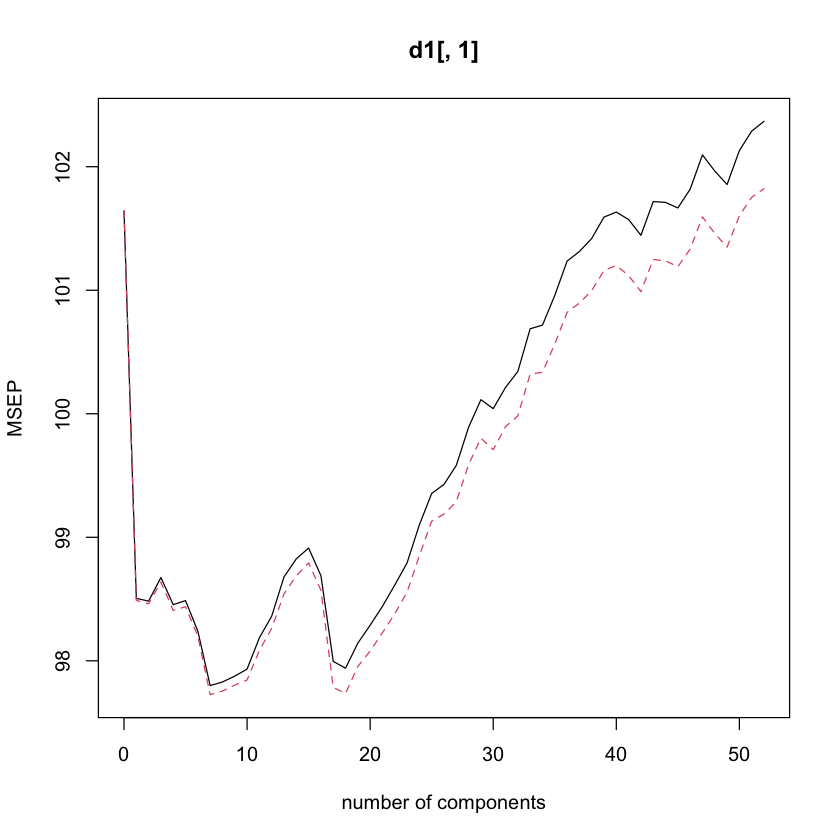

In [45]:
validationplot(pcr.fit,val.type="MSEP") # MSEP shows cross-validated mean-squared error as error metric

(c) Extract the MSEP values of the cross validated fit ("CV" not "adj_CV") from the model object using the `MSEP` funtion. Create a new array of these values. Use the `drop` function to remove the singleton dimension (the original array is 2x1x53 and we want a 2x53 object). Find the minimum value of the first row (the "CV").

In [71]:
msep_obj <- MSEP(pcr.fit)
#class(msep_obj)
msep_obj
length(msep_obj)


       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV           101.6    98.51    98.48    98.67    98.45    98.49    98.24
adjCV        101.6    98.49    98.46    98.64    98.41    98.44    98.20
       7 comps  8 comps  9 comps  10 comps  11 comps  12 comps  13 comps
CV       97.80    97.83    97.88     97.93     98.19     98.36     98.68
adjCV    97.73    97.75    97.80     97.84     98.08     98.26     98.54
       14 comps  15 comps  16 comps  17 comps  18 comps  19 comps  20 comps
CV        98.83     98.91     98.69     98.00     97.94     98.14     98.29
adjCV     98.69     98.79     98.57     97.78     97.74     97.95     98.08
       21 comps  22 comps  23 comps  24 comps  25 comps  26 comps  27 comps
CV        98.44     98.61     98.79     99.10     99.35     99.43     99.58
adjCV     98.23     98.38     98.56     98.85     99.13     99.19     99.29
       28 comps  29 comps  30 comps  31 comps  32 comps  33 comps  34 comps
CV        99.89     100.1    1

[1] 5

What what does this plot tell you about how many components best explain variance in Flanker task performance?

> I couldn't plot it because I got stuck inside the dimesions/format of the MSEP output, but based on eyeballing the printed results, it looks like the lowest value of CV is for PC#11. So 11 components must be enough to explain the variance in the Flanker task performance. 
> *

---
## 5. Reflection (2 points)

Compare the number of components that explain variance in X alone (the brain volumes) to the number of components that explain performance in the Flanker task. What does the difference in these two numbers tell you about how variation in brain volumes relates to task performance?

> *Write your response here*

> It tells me that the variation in brain volumes as it relates to task peformance has fewer dimensions (more shared variance between dimensions) than the variation in the brain volumes per se. 

**DUE:** 11:59pm EST, April 9, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*